First Markdown heading inside notebook:
Diabetes Health Indicators
Data Quality Assessment & Exploratory Analysis

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


In [2]:
os.listdir('/kaggle/input')

['datasets']

In [3]:
os.listdir('/kaggle/input/datasets')

['alexteboul']

In [4]:
os.listdir('/kaggle/input/datasets/alexteboul')

['diabetes-health-indicators-dataset']

In [5]:
os.listdir('/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset')

['diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
 'diabetes_binary_health_indicators_BRFSS2015.csv',
 'diabetes_012_health_indicators_BRFSS2015.csv']

In [6]:
df = pd.read_csv(
    '/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv'
)

In [7]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [8]:
df.shape

(253680, 22)

In [9]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [11]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(23899)

In [13]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0


In [14]:
df['Diabetes_012'].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [15]:
df['Diabetes_012'].value_counts(normalize=True) * 100

Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64

In [16]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


Diabetes_012
[0. 2. 1.]

HighBP
[1. 0.]

HighChol
[1. 0.]

CholCheck
[1. 0.]

BMI
[40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]

Smoker
[1. 0.]

Stroke
[0. 1.]

HeartDiseaseorAttack
[0. 1.]

PhysActivity
[0. 1.]

Fruits
[0. 1.]

Veggies
[1. 0.]

HvyAlcoholConsump
[0. 1.]

AnyHealthcare
[1. 0.]

NoDocbcCost
[0. 1.]

GenHlth
[5. 3. 2. 4. 1.]

MentHlth
[18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]

PhysHlth
[15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]

DiffWalk
[1. 0.]

Sex
[0. 1.]

Age
[ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3

In [17]:
df['BMI'].describe()

count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64

In [18]:
df['BMI'].value_counts().sort_index()

BMI
12.0      6
13.0     21
14.0     41
15.0    132
16.0    348
       ... 
91.0      1
92.0     32
95.0     12
96.0      1
98.0      7
Name: count, Length: 84, dtype: int64

## Project Overview

This project explores health and lifestyle factors associated with diabetes using data from the 2015 Behavioral Risk Factor Surveillance System (BRFSS).

The dataset contains 253,680 survey responses and 21 health-related predictor variables, including BMI, blood pressure, cholesterol, physical activity, smoking status, age, education, and income.

The goal of this project is to assess data quality, explore patterns within the dataset, and identify factors associated with diabetes and prediabetes using Python.

### Project Objectives
- Assess the structure and quality of the dataset
- Validate missing values, duplicates, variable ranges, and data types
- Explore the distribution of diabetes and prediabetes
- Analyze relationships between diabetes status and key health indicators
- Create clear visualizations to communicate findings

## 1. Data Loading and Initial Inspection

In [19]:
df = pd.read_csv(
    '/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv'
)

In [20]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [21]:
df.shape

(253680, 22)

In [22]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

## 2. Data Quality Assessment

### 2.1 Missing Values


In [24]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

No standard null values were identified across the 253,680 observations and 22 variables. However, because BRFSS variables may use coded responses, variable values were also examined to identify potentially unexpected or invalid values.

### 2.2 Duplicate Records

In [25]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(23899)

A total of 23,899 rows were identified as exact duplicates across all 22 variables. Because the dataset does not contain a unique respondent identifier and many variables are categorical or binary, identical response patterns may represent different respondents rather than duplicate data-entry records. Duplicate observations were therefore investigated before making a removal decision.

In [26]:
df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
).head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0


### 2.3 Value Validation

In [27]:
for column in df.columns:
    if df[column].nunique() <= 15:
        print(f"\n{column}")
        print(sorted(df[column].unique()))


Diabetes_012
[np.float64(0.0), np.float64(1.0), np.float64(2.0)]

HighBP
[np.float64(0.0), np.float64(1.0)]

HighChol
[np.float64(0.0), np.float64(1.0)]

CholCheck
[np.float64(0.0), np.float64(1.0)]

Smoker
[np.float64(0.0), np.float64(1.0)]

Stroke
[np.float64(0.0), np.float64(1.0)]

HeartDiseaseorAttack
[np.float64(0.0), np.float64(1.0)]

PhysActivity
[np.float64(0.0), np.float64(1.0)]

Fruits
[np.float64(0.0), np.float64(1.0)]

Veggies
[np.float64(0.0), np.float64(1.0)]

HvyAlcoholConsump
[np.float64(0.0), np.float64(1.0)]

AnyHealthcare
[np.float64(0.0), np.float64(1.0)]

NoDocbcCost
[np.float64(0.0), np.float64(1.0)]

GenHlth
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

DiffWalk
[np.float64(0.0), np.float64(1.0)]

Sex
[np.float64(0.0), np.float64(1.0)]

Age
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(1

Most categorical variables contained the expected limited set of coded values. No obvious invalid categories were identified during this initial validation. Variables such as Age, Education, Income, and General Health are coded categories rather than literal numerical measurements and should therefore be interpreted using the BRFSS coding scheme.

### 2.4 Numerical Range and Outlier Review

In [28]:
df[['BMI', 'MentHlth', 'PhysHlth']].describe()

,BMI,MentHlth,PhysHlth
count,253680.000000,253680.000000,253680.000000
mean,28.382364,3.184772,4.242081
std,6.608694,7.412847,8.717951
min,12.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000
75%,31.000000,2.000000,3.000000
max,98.000000,30.000000,30.000000


BMI values ranged from 12 to 98. Although extreme BMI values were present, they were retained because they are physiologically possible and there was insufficient evidence to classify them as data errors.

Mental and physical health day variables ranged from 0 to 30, which is consistent with their intended measurement as the number of poor health days experienced during the previous 30 days. No values outside the expected range were identified.

### 2.5 Data Quality Summary

The dataset was found to be largely analysis-ready. No standard missing values or obvious invalid category codes were identified. Exact duplicate response patterns were present but were retained because no unique respondent identifier was available to determine whether they represented true duplicate records. Extreme BMI values were also retained because they remained plausible.

Because the Kaggle dataset had already been cleaned and consolidated from the original BRFSS 2015 data, no observations were removed during this assessment. Subsequent analysis will therefore focus on understanding patterns and relationships within the validated dataset.

## 3. Exploratory Data Analysis

### 3.1 Diabetes Status Distribution

The target variable, `Diabetes_012`, categorizes respondents as having no diabetes, prediabetes, or diabetes. The distribution of these groups was examined to understand the prevalence of each outcome within the dataset.

In [29]:
diabetes_counts = df['Diabetes_012'].value_counts().sort_index()
diabetes_counts

Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

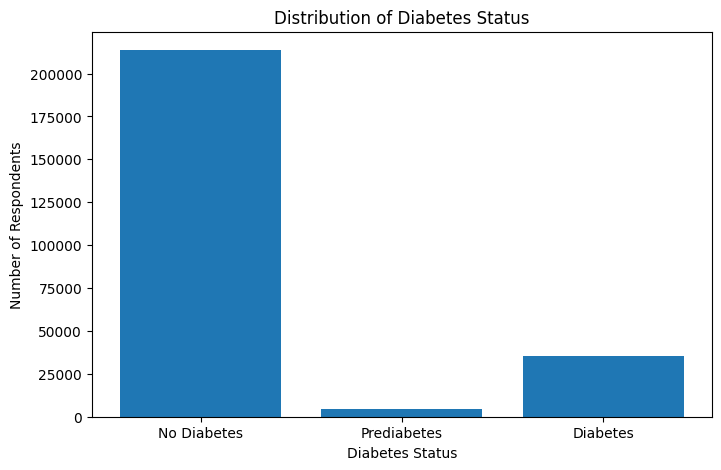

In [30]:
import matplotlib.pyplot as plt

diabetes_labels = ['No Diabetes', 'Prediabetes', 'Diabetes']

plt.figure(figsize=(8, 5))
plt.bar(diabetes_labels, diabetes_counts.values)

plt.title('Distribution of Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Number of Respondents')

plt.show()

#### Interpretation

The dataset shows a substantial imbalance in diabetes status. Approximately 84.2% of respondents were classified as having no diabetes, while 13.9% had diabetes and only 1.8% were classified as having prediabetes.

The relatively small prediabetes group is important to consider when interpreting subsequent analyses and would require particular attention if this dataset were later used for predictive modeling.

### 3.2 BMI and Diabetes Status

BMI is an established health indicator associated with metabolic health. Mean BMI was compared across diabetes-status groups to examine whether BMI differs between respondents with no diabetes, prediabetes, and diabetes.

In [31]:
bmi_by_diabetes = df.groupby('Diabetes_012')['BMI'].mean()
bmi_by_diabetes


Diabetes_012
0.0    27.742521
1.0    30.724466
2.0    31.944011
Name: BMI, dtype: float64

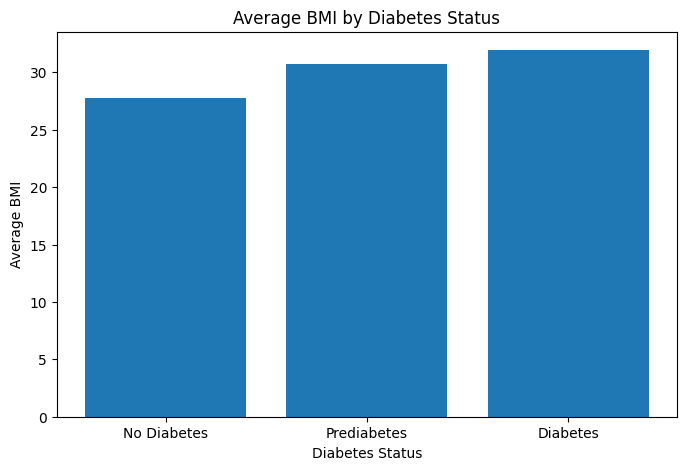

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(diabetes_labels, bmi_by_diabetes.values)

plt.title('Average BMI by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Average BMI')

plt.show()

#### Interpretation

Average BMI increased across diabetes-status groups. Respondents without diabetes had a mean BMI of approximately 27.7, compared with 30.7 among respondents with prediabetes and 31.9 among respondents with diabetes.

This pattern suggests an association between higher BMI and diabetes status within the survey population. However, this descriptive analysis does not establish that higher BMI causes diabetes.

### 3.3 High Blood Pressure and Diabetes Status

High blood pressure is an important cardiovascular and metabolic health indicator. The prevalence of high blood pressure was compared across diabetes-status groups to examine its relationship with diabetes.

In [33]:
highbp_by_diabetes = df.groupby('Diabetes_012')['HighBP'].mean() * 100
highbp_by_diabetes

Diabetes_012
0.0    37.113190
1.0    62.902181
2.0    75.267357
Name: HighBP, dtype: float64

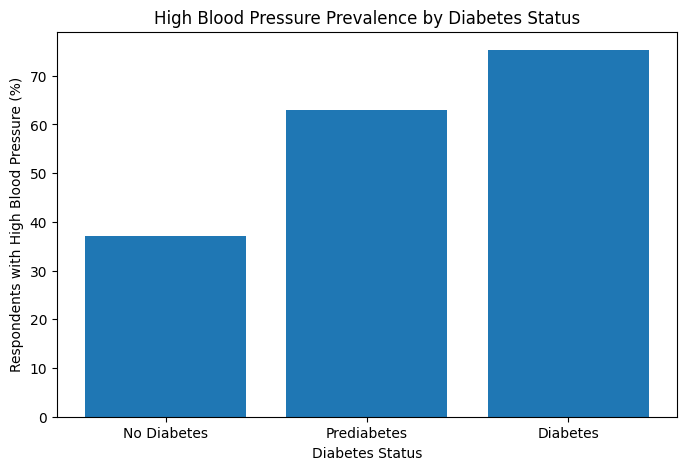

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(diabetes_labels, highbp_by_diabetes.values)

plt.title('High Blood Pressure Prevalence by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Respondents with High Blood Pressure (%)')

plt.show()

#### Interpretation

High blood pressure was substantially more common among respondents with prediabetes and diabetes. Approximately 37.1% of respondents without diabetes reported high blood pressure, compared with 62.9% of respondents with prediabetes and 75.3% of respondents with diabetes.

These results indicate a strong descriptive association between high blood pressure and diabetes status in this dataset. However, the analysis does not establish a causal relationship.

### 3.4 Age and Diabetes Status

Age is represented in the BRFSS dataset as an ordinal category rather than a respondent's exact age. The distribution of diabetes status across age categories was examined to explore how diabetes prevalence varies with age.

In [35]:
age_diabetes = pd.crosstab(
    df['Age'],
    df['Diabetes_012'],
    normalize='index'
) * 100

age_diabetes.head()

Diabetes_012,0.0,1.0,2.0
Age,,,
1.0,98.263158,0.368421,1.368421
2.0,97.446696,0.710713,1.842590
3.0,96.529713,0.647307,2.822979
4.0,94.444043,1.027273,4.528684
5.0,92.486229,1.008851,6.504920


In [36]:
age_diabetes

Diabetes_012,0.0,1.0,2.0
Age,,,
1.0,98.263158,0.368421,1.368421
2.0,97.446696,0.710713,1.842590
3.0,96.529713,0.647307,2.822979
4.0,94.444043,1.027273,4.528684
5.0,92.486229,1.008851,6.504920
6.0,89.636208,1.574247,8.789545
7.0,86.676294,1.588508,11.735198
8.0,84.389595,1.783861,13.826544
9.0,80.643124,2.111659,17.245217


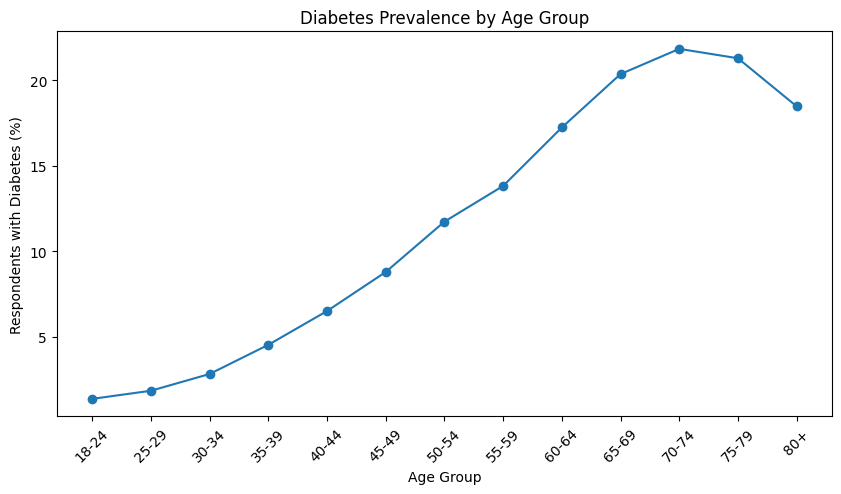

In [37]:
age_labels = [
    '18-24', '25-29', '30-34', '35-39', '40-44',
    '45-49', '50-54', '55-59', '60-64', '65-69',
    '70-74', '75-79', '80+'
]

diabetes_by_age = age_diabetes[2.0]

plt.figure(figsize=(10, 5))

plt.plot(age_labels, diabetes_by_age.values, marker='o')

plt.title('Diabetes Prevalence by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Respondents with Diabetes (%)')
plt.xticks(rotation=45)

plt.show()

#### Interpretation

Diabetes prevalence generally increased across age groups. Approximately 1.4% of respondents in the youngest age category had diabetes, compared with more than 20% among several older age groups.

Prevalence reached its highest observed level in the 70–74 age group at approximately 21.8%, before declining somewhat among the oldest respondents. Overall, the pattern demonstrates a strong descriptive association between age and diabetes status in the BRFSS sample.


### 3.5 Physical Activity and Diabetes Status

Physical activity is an important modifiable lifestyle factor related to overall metabolic health. The percentage of respondents reporting physical activity was compared across diabetes-status groups.

In [38]:
activity_by_diabetes = df.groupby('Diabetes_012')['PhysActivity'].mean() * 100
activity_by_diabetes

Diabetes_012
0.0    77.907657
1.0    67.847117
2.0    63.053811
Name: PhysActivity, dtype: float64

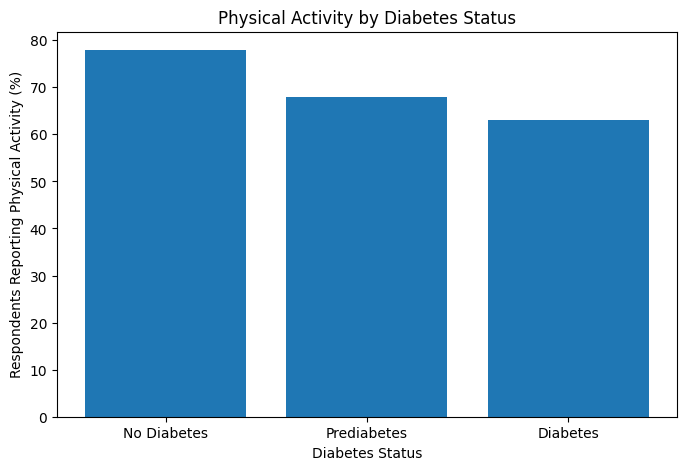

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(diabetes_labels, activity_by_diabetes.values)

plt.title('Physical Activity by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Respondents Reporting Physical Activity (%)')

plt.show()

#### Interpretation

Reported physical activity decreased across diabetes-status groups. Approximately 77.9% of respondents without diabetes reported physical activity, compared with 67.8% of respondents with prediabetes and 63.1% of respondents with diabetes.

This pattern suggests an association between diabetes status and lower reported physical activity within the survey population. Because this analysis is observational and cross-sectional, it does not establish the direction or cause of this relationship.

### 3.6 General Health and Diabetes Status

Self-reported general health provides a broader measure of perceived health status. General health ratings were compared across diabetes-status groups to examine whether respondents with diabetes reported poorer overall health.

In [40]:
genhlth_by_diabetes = df.groupby('Diabetes_012')['GenHlth'].mean()
genhlth_by_diabetes

Diabetes_012
0.0    2.372391
1.0    2.975599
2.0    3.290981
Name: GenHlth, dtype: float64

In [41]:
genhlth_distribution = pd.crosstab(
    df['GenHlth'],
    df['Diabetes_012'],
    normalize='columns'
) * 100

genhlth_distribution

Diabetes_012,0.0,1.0,2.0
GenHlth,,,
1.0,20.517260,6.758799,3.225259
2.0,38.131893,26.214640,18.052962
3.0,28.292069,37.313755,38.072201
4.0,9.712077,22.133448,27.697618
5.0,3.346701,7.579357,12.951961


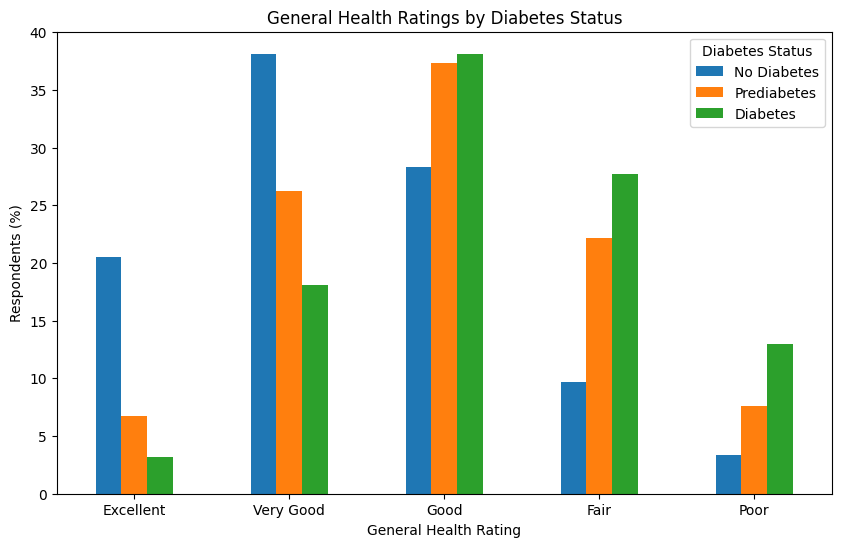

In [42]:
genhlth_labels = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']

genhlth_plot = genhlth_distribution.copy()
genhlth_plot.index = genhlth_labels
genhlth_plot.columns = diabetes_labels

genhlth_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('General Health Ratings by Diabetes Status')
plt.xlabel('General Health Rating')
plt.ylabel('Respondents (%)')
plt.xticks(rotation=0)
plt.legend(title='Diabetes Status')

plt.show()

#### Interpretation

Self-reported general health differed substantially across diabetes-status groups. Approximately 58.6% of respondents without diabetes rated their health as Excellent or Very Good, compared with only 21.3% of respondents with diabetes.

Conversely, approximately 40.6% of respondents with diabetes reported Fair or Poor general health, compared with 13.1% of respondents without diabetes. These findings demonstrate a strong descriptive association between diabetes status and poorer self-reported general health.

### 3.7 Income and Diabetes Status

Income was examined as a socioeconomic factor potentially associated with diabetes prevalence. Because income is represented as an ordered categorical variable, diabetes prevalence was compared across income categories.

In [43]:
income_diabetes = pd.crosstab(
    df['Income'],
    df['Diabetes_012'],
    normalize='index'
) * 100

income_diabetes

Diabetes_012,0.0,1.0,2.0
Income,,,
1.0,72.510447,3.200489,24.289063
2.0,70.788424,3.021302,26.190274
3.0,75.059397,2.632237,22.308366
4.0,77.586293,2.279613,20.134095
5.0,80.330719,2.267898,17.401383
6.0,83.441185,2.051001,14.507815
7.0,86.117217,1.700641,12.182142
8.0,90.921060,1.118548,7.960392


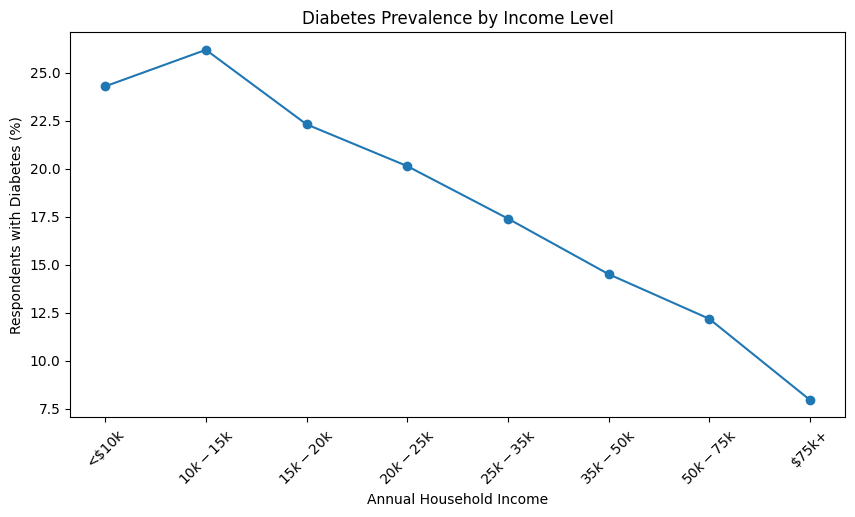

In [44]:
income_labels = [
    '<$10k',
    '$10k-$15k',
    '$15k-$20k',
    '$20k-$25k',
    '$25k-$35k',
    '$35k-$50k',
    '$50k-$75k',
    '$75k+'
]

diabetes_by_income = income_diabetes[2.0]

plt.figure(figsize=(10, 5))

plt.plot(
    income_labels,
    diabetes_by_income.values,
    marker='o'
)

plt.title('Diabetes Prevalence by Income Level')
plt.xlabel('Annual Household Income')
plt.ylabel('Respondents with Diabetes (%)')
plt.xticks(rotation=45)

plt.show()

#### Interpretation

Diabetes prevalence generally decreased as household income increased. Approximately 24.3% of respondents in the lowest income category had diabetes, compared with approximately 8.0% of respondents in the highest income category.

Although the pattern was not perfectly linear across the lowest income groups, the overall trend indicates a descriptive association between lower household income and higher diabetes prevalence. This relationship should not be interpreted as causal, as other health, demographic, and socioeconomic factors may contribute to the observed differences.

## 4. Key Findings and Conclusion

### Key Findings

This exploratory analysis identified several notable patterns associated with diabetes status in the BRFSS 2015 sample:

- **BMI:** Average BMI increased across diabetes-status groups, from 27.7 among respondents without diabetes to 30.7 among those with prediabetes and 31.9 among those with diabetes.
- **High blood pressure:** High blood pressure was reported by 37.1% of respondents without diabetes, compared with 62.9% of respondents with prediabetes and 75.3% of respondents with diabetes.
- **Age:** Diabetes prevalence generally increased with age, reaching its highest observed prevalence of approximately 21.8% among respondents ages 70–74.
- **Physical activity:** Reported physical activity was lower among respondents with diabetes. Approximately 63.1% of respondents with diabetes reported physical activity compared with 77.9% of respondents without diabetes.
- **General health:** Respondents with diabetes reported substantially poorer overall health. Approximately 40.6% of respondents with diabetes rated their health as Fair or Poor compared with 13.1% of respondents without diabetes.
- **Income:** Diabetes prevalence generally decreased as household income increased. Approximately 24.3% of respondents in the lowest income category had diabetes compared with approximately 8.0% in the highest income category.

### Conclusion

The analysis demonstrates clear descriptive relationships between diabetes status and several health, demographic, lifestyle, and socioeconomic indicators. Respondents with diabetes tended to have higher BMI, higher prevalence of high blood pressure, lower reported physical activity, poorer self-reported general health, and higher diabetes prevalence within older and lower-income groups.

These findings should be interpreted as associations rather than causal relationships. The BRFSS data are observational and based largely on self-reported survey responses, meaning the analysis cannot determine whether any individual factor directly causes diabetes. The substantial imbalance among diabetes-status groups should also be considered if the dataset is used for future predictive modeling.

Overall, this project demonstrates the use of Python and pandas for data validation, exploratory data analysis, aggregation, and visualization of a large public-health dataset.

## 5. Tools and Skills Demonstrated

- Python
- pandas
- NumPy
- Matplotlib
- Data quality assessment
- Data validation
- Exploratory data analysis (EDA)
- Categorical and numerical data analysis
- Data visualization
- Interpretation of public-health data